### Overview
We will learn how to work with landcover data and calculate area of different landcover classes in a region. This section also shows how you can scale your analysis to large regions without running into memory limits using `dask`.

### Setup

Determine our runtime environment.


In [ ]:
import os

if 'COLAB_RELEASE_TAG' in os.environ:
    environment = 'colab'
    if os.environ.get('VERTEX_PRODUCT') == 'COLAB_ENTERPRISE':
        environment = 'colab_enterprise'
else:
    environment = 'local'

# Set to True to use Google Drive for data storage in Colab
use_google_drive = True

# Google Drive is available only in 'colab' environment
if environment == 'colab' and use_google_drive:
    from google.colab import drive
    drive.mount('/content/drive')
    drive_folder_root = 'MyDrive'
    drive_data_folder = 'python-remote-sensing'
    drive_folder_path = os.path.join('/content/drive', drive_folder_root, drive_data_folder)
    data_folder = drive_folder_path
    output_folder = drive_folder_path
else:
    data_folder = 'data'
    output_folder = 'output'

if not os.path.exists(data_folder):
    os.mkdir(data_folder)
if not os.path.exists(output_folder):
    os.mkdir(output_folder)

print(f'Environment: {environment}')
print(f'Data folder: {data_folder}')
print(f'Output folder: {output_folder}')

If we are on Google Colab, install the required packages. Local runtimes are expected to have the packages already installed.

In [ ]:
%%capture
if environment in ['colab', 'colab_enterprise']:
  !pip install pystac-client odc-stac rioxarray dask[distributed] \
      jupyter-server-proxy planetary_computer

Import all required libraries. Make sure to import everything at the beginning as certain Xarray extensions are activated on import and registers certain accesors, like `.rio` and `.odc` for Xarray objects.

In [ ]:
import dask.array as da
import geopandas as gpd
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import planetary_computer as pc
import pyproj
import pystac_client
import rioxarray as rxr
import xarray as xr
from matplotlib import cm
from odc import stac
from odc.geo.geobox import GeoBox
from affine import Affine
import rasterio.features

Setup a local Dask cluster. This distributes the computation across multiple workers on your computer.

In [ ]:
from dask.distributed import Client
client = Client()  # set up local cluster on the machine
client

If you are running this notebook in Colab, you will need to create and use a proxy URL to see the dashboard running on the local server.

In [ ]:
if environment == 'colab':
    from google.colab import output
    port_to_expose = 8787  # This is the default port for Dask dashboard
    print(output.eval_js(f'google.colab.kernel.proxyPort({port_to_expose})'))

### Load Area of Interest

Read the file containing the city boundary.

In [ ]:
aoi_filepath = os.path.join(data_folder, 'aoi.geojson')

if not os.path.exists(aoi_filepath):
    print(f'AOI file not found at {aoi_filepath}. Using default AOI.')
    aoi_filepath = ('https://storage.googleapis.com/spatialthoughts-public-data'
                    '/python-remote-sensing/aoi.geojson')

Read the GeoJSON.

In [ ]:
aoi_gdf = gpd.read_file(aoi_filepath)

Extract the geometry.

In [ ]:
geometry = aoi_gdf.geometry.union_all()
geometry

### Get ESA WorldCover Data

Let's use [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-stac/) search endpoint to look for items from the ESA WorldCover collection on Azure Blob Storage.

ESA WorldCover has data for year 2020 and 2021. We will use the 2021 data.

In [ ]:
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1')

search = catalog.search(
    collections=['esa-worldcover'],
    intersects=geometry,
    datetime=f'2021', # Data available only for years 2020 and 2021
)
items = search.item_collection()
items

Each STAC item has metadata containing information about the class names, legend colors and pixel values. Let's extract it so we can use it later to contruct a meaningful legend.

In [ ]:
class_list = items[0].assets['map'].extra_fields['classification:classes']
class_dict = {
    c['value']: {'description': c['description'], 'hex': c['color_hint']}
    for c in class_list
}
class_dict

Load the matching images as a XArray Dataset. Accessing data from Planetary Computer is free but requires getting a Shared Access Signature (SAS) token and sign the URLs. The `planetary_computer` Python package provides a simple mechanism for signing the URLs using `sign()` function.

In [ ]:
# Load to XArray
ds = stac.load(
    items,
    bbox=geometry.bounds, # <-- load data only for the bbox
    resolution=10,
    crs='utm',
    chunks={'x': 1024, 'y': 1024},  # Explicitly define chunk sizes
    patch_url=pc.sign,
    groupby='solar_day',
    preserve_original_order=True
)
ds

The landcover classification data is in the `map` variable. Select it and remove the empty `time` dimension.

In [ ]:
map_data = ds['map'].squeeze()
map_data

Run this computation using the local Dask cluster and load the data into memory using `.compute()`.

In [ ]:
%%time
map_data = map_data.compute()

Clip the data to the buffered region. Before we clip, we need to reproject the `aoi_gdf` to the same CRS as the data.

In [ ]:
aoi_gdf_reprojected = aoi_gdf.to_crs(map_data.rio.crs)
map_data_clipped = map_data.rio.clip(aoi_gdf_reprojected.geometry)

### Visualize the Landcover

To create a meaningful legend, we use the class names and colors from the `class_dict` created earlier.

In [ ]:
colors = ['#000000' for r in range(256)]
for key, value in class_dict.items():
    colors[int(key)] = f'#{value['hex']}'

# Set color for value 0 to transparent
colors[0] = (0, 0, 0, 0)
cmap = matplotlib.colors.ListedColormap(colors)

# Data range is 8-bit (0-255)
normalizer = matplotlib.colors.Normalize(vmin=0, vmax=255)

# Set tick labels
values = [key for key in class_dict]
boundaries = [(values[i + 1] + values[i]) / 2 for i in range(len(values) - 1)]
boundaries = [0] + boundaries + [255]
ticks = [
    (boundaries[i + 1] + boundaries[i]) / 2
    for i in range(len(boundaries) - 1)
]
tick_labels = [
    f'{value['description']} ({key})'
     for key, value in class_dict.items()
]
tick_labels

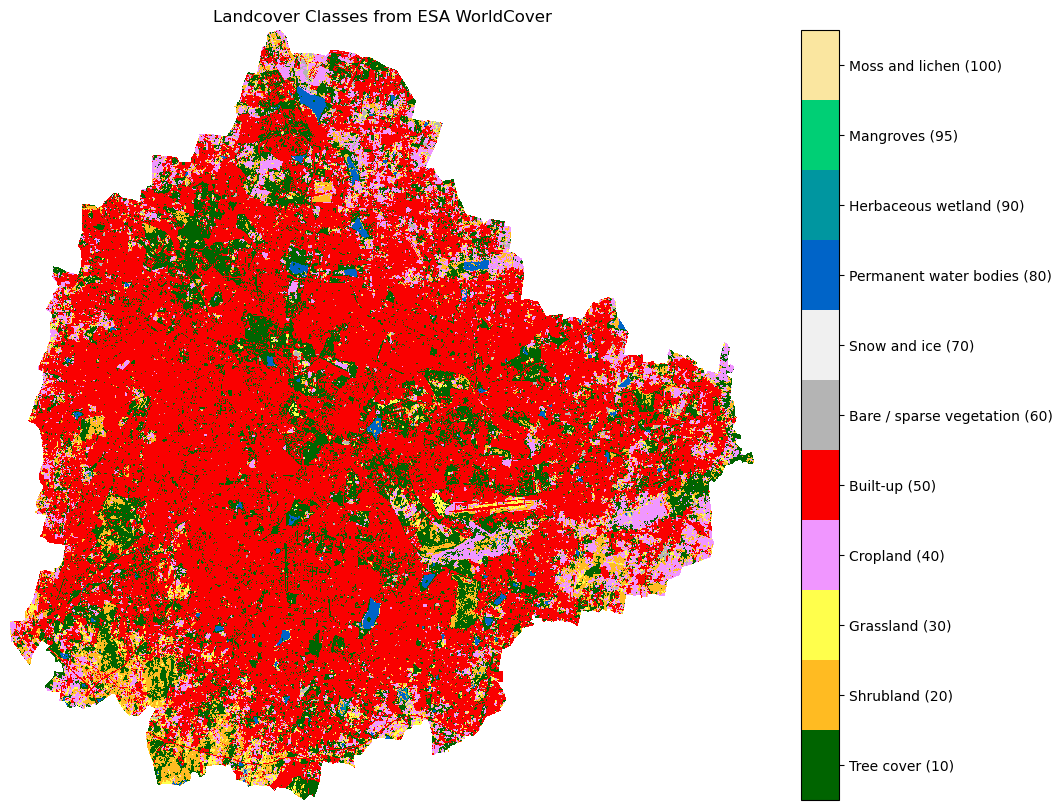

In [18]:
fig, ax = plt.subplots(1, 1)
fig.set_size_inches(12, 10)

map_data_clipped.plot(
    ax=ax, cmap=cmap, norm=normalizer
)

colorbar = fig.colorbar(
    cm.ScalarMappable(norm=normalizer, cmap=cmap),
    boundaries=boundaries,
    values=values,
    cax=fig.axes[1].axes,
)
colorbar.set_ticks(ticks, labels=tick_labels)

ax.set_axis_off()
ax.set_title('Landcover Classes from ESA WorldCover');

### Calculate Area

We can now calculate are of each class in our region of interest. As our data is in a projected CRS, each pixel's area is fixed. We can count the total number of pixels for each class and multiply it by the area of a single pixel to get the area.

Let's get the underlying array of pixel values.

In [ ]:
data = map_data_clipped.values

To efficiently get the pixel counts of all unique pixel values in the data, we can use `histogram()` function provided by NumPy. The function takes an array of values and returns counts of each pixel value. We need to specify the bins to be used. Since we need counts for each class, we can use the class values as bins.

In [ ]:
# Get unique class values to define histogram bins
unique_classes = sorted(class_dict.keys())
# right edge for last bin
bins = unique_classes + [unique_classes[-1] + 1]

counts, _ = np.histogram(data, bins=bins)
counts

We now have pixel counts of each class. We multiply it by the area of each pixel to get the area. We can also filter out pixels with value 0 (nodata pixels) and counts 0 (not present in the region) to get a clean table.

In [ ]:
pixel_area_m2 = 100.0

area_df = pd.DataFrame({
    'class_value': unique_classes,
    'area_m2': counts * pixel_area_m2,
})

area_df['class_name'] = area_df['class_value'].map(
    lambda x: class_dict[x]['description'])

# Drop nodata class (0) and classes with no pixels
area_df = area_df[
    (area_df['class_value'] != 0) & (area_df['area_m2'] > 0)]

area_df

Save the results as a CSV file.

In [ ]:
output_filename = f'aoi_area.csv'
output_filepath = os.path.join(output_folder, output_filename)
area_df.to_csv(output_filepath, index=False)

### Exercise

Select only the pixels of *Tree Cover* (class value `10`) to create a map of tree cover in your region. Save the result as a Cloud-Optimized GeoTIFF (COG).

Hint: Use the [`where()`](https://docs.xarray.dev/en/stable/generated/xarray.DataArray.where.html) function.